## Data Load & Pre Processing

In [ ]:
# CELL 1: SETUP AND IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from imblearn.over_sampling import SMOTE # Ensure 'imbalanced-learn' is installed

# Make sure plots show up inline in the notebook
%matplotlib inline

print("Imports successful.")

Imports successful.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 2: LOAD DATA
df = pd.read_csv("/content/parkinsons_updrs.data")

# Extract Baseline (Patient's first visit)
baseline_idx = df.groupby('subject#')['test_time'].idxmin()
baseline_df = df.loc[baseline_idx].copy()

# Extract only the voice features
voice_cols = [col for col in df.columns if col not in
              ['subject#', 'age', 'sex', 'test_time', 'motor_UPDRS', 'total_UPDRS']]

rename_dict = {col: f"baseline_{col}" for col in voice_cols + ['total_UPDRS']}
baseline_df = baseline_df[['subject#'] + list(rename_dict.keys())].rename(columns=rename_dict)
df = df.merge(baseline_df, on='subject#')

# Calculate Deltas (Rate of change)
df['delta_UPDRS'] = df['total_UPDRS'] - df['baseline_total_UPDRS']
for col in voice_cols:
    df[f"delta_{col}"] = df[col] - df[f"baseline_{col}"]

# Target: Severe & Worsening
df['severe_and_worse'] = np.where(
    (df['total_UPDRS'] >= 35) & (df['delta_UPDRS'] > 2), 1, 0
)

print(f"Data engineered successfully. Shape: {df.shape}")

Data engineered successfully. Shape: (5875, 57)


## Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create a folder to save images if it doesn't exist
os.makedirs('/content/drive/MyDrive/Colab Data/EDA_Plots', exist_ok=True)
save_dir = '/content/drive/MyDrive/Colab Data/EDA_Plots/'

# Set global theme for all following plots
sns.set_theme(style="whitegrid", context="talk")
custom_palette = {0: "#4C72B0", 1: "#C44E52"} # Blue for Stable, Red for Severe/Worsening

#### 1. Target Class Distribution
First, we must evaluate the balance of our target variable (`severe_and_worse`).

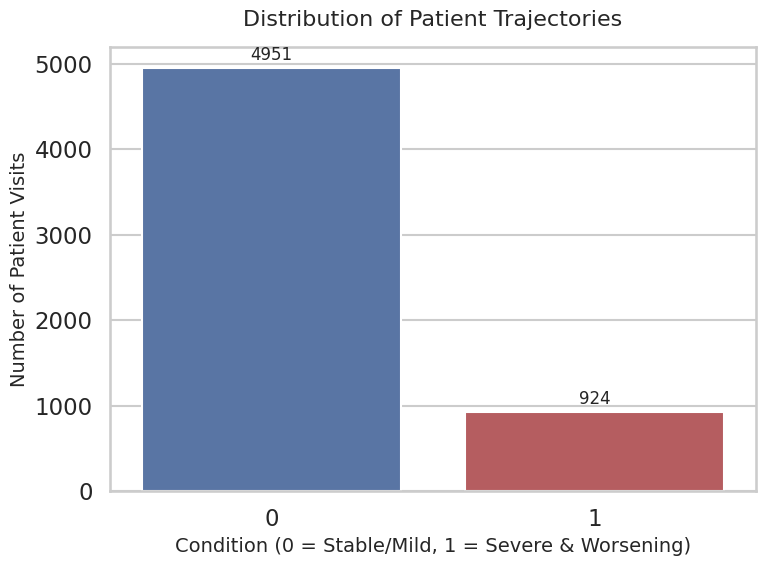

In [ ]:
plt.figure(figsize=(8, 6))

# Create the count plot
ax = sns.countplot(data=df, x='severe_and_worse', hue='severe_and_worse', palette=custom_palette, legend=False)

# Add numeric labels to the top of each bar for readability
for container in ax.containers:
    ax.bar_label(container, padding=3, size=12)

# Clean up titles and labels
plt.title('Distribution of Patient Trajectories', fontsize=16, pad=15)
plt.xlabel('Condition (0 = Stable/Mild, 1 = Severe & Worsening)', fontsize=14)
plt.ylabel('Number of Patient Visits', fontsize=14)

# Display and Save
plt.tight_layout()
plt.savefig(f'{save_dir}1_class_distribution.png', dpi=300)
plt.show()

**Interpretation:**
This chart reveals a massive **class imbalance**. The vast majority of patient records belong to Class 0 (Stable/Mild), while Class 1 (Severe & Worsening) is the minority. If we feed this directly into a machine learning model, it will become biased toward predicting "Class 0" simply because it is the most common outcome. This validates our need to use **SMOTE** later in the pipeline to synthetically balance the training data.

#### 2. Baseline Severity vs. Future Trajectory

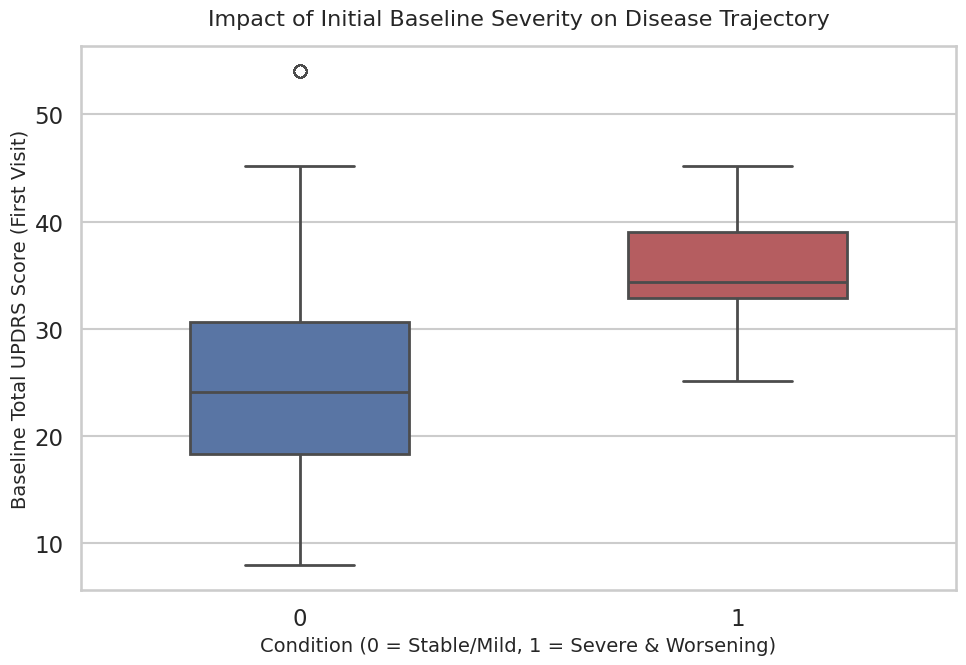

In [ ]:
plt.figure(figsize=(10, 7))

# Create the boxplot
sns.boxplot(
    data=df,
    x='severe_and_worse',
    y='baseline_total_UPDRS',
    hue='severe_and_worse',
    palette=custom_palette,
    legend=False,
    width=0.5,
    linewidth=2
)

plt.title('Impact of Initial Baseline Severity on Disease Trajectory', fontsize=16, pad=15)
plt.xlabel('Condition (0 = Stable/Mild, 1 = Severe & Worsening)', fontsize=14)
plt.ylabel('Baseline Total UPDRS Score (First Visit)', fontsize=14)

# Display and Save
plt.tight_layout()
plt.savefig(f'{save_dir}2_baseline_severity.png', dpi=300)
plt.show()

**Interpretation:**
The boxplot demonstrates a clear distinction between the two groups. Patients who eventually fall into the "Severe and Worsening" category (Class 1) tend to have a significantly higher median `baseline_total_UPDRS` score at their very first visit. This suggests that the initial state of the disease is a strong predictive indicator of future rapid decline.

#### 3. Voice Degradation (Jitter) over Time

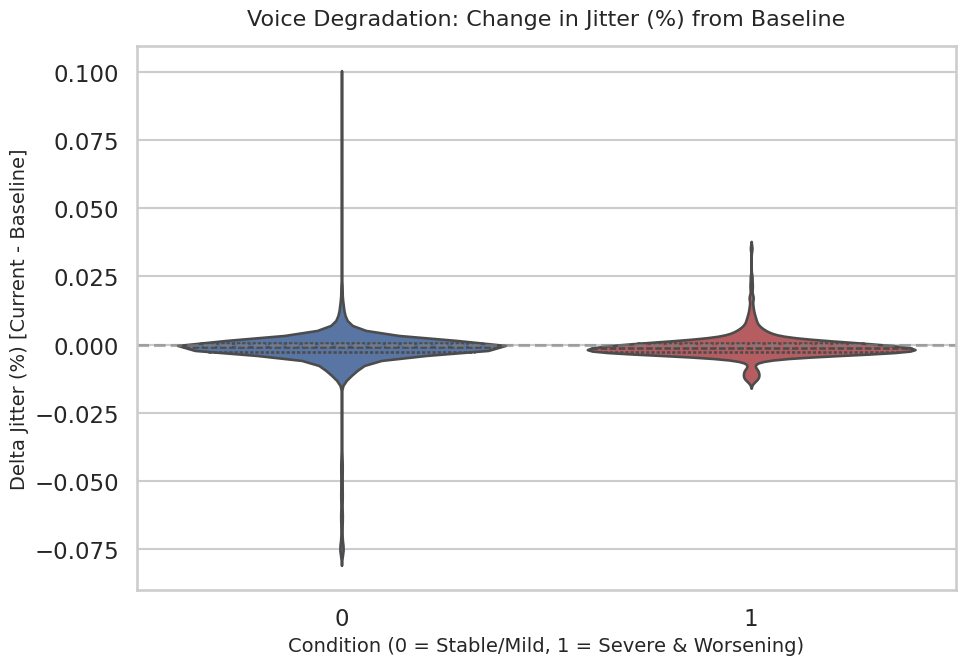

In [ ]:
plt.figure(figsize=(10, 7))

# Create the violin plot
sns.violinplot(
    data=df,
    x='severe_and_worse',
    y='delta_Jitter(%)',
    hue='severe_and_worse',
    palette=custom_palette,
    legend=False,
    inner="quartile" # Shows the median and quartiles inside the violin
)

plt.title('Voice Degradation: Change in Jitter (%) from Baseline', fontsize=16, pad=15)
plt.xlabel('Condition (0 = Stable/Mild, 1 = Severe & Worsening)', fontsize=14)
plt.ylabel('Delta Jitter (%) [Current - Baseline]', fontsize=14)

# Add a horizontal line at 0 to show "No Change"
plt.axhline(0, color='gray', linestyle='--', alpha=0.6)

# Display and Save
plt.tight_layout()
plt.savefig(f'{save_dir}3_voice_degradation.png', dpi=300)
plt.show()

**Interpretation:**
This violin plot maps the probability density of the change in voice jitter. The dashed gray line represents zero change from baseline. While both groups hover around the baseline, Class 1 (Severe & Worsening) exhibits a wider spread and longer "tails"—meaning these patients are much more likely to experience extreme, erratic shifts (both increases and decreases) in their vocal jitter compared to the stable group.

#### 4. Multicollinearity Check (Feature Correlation)

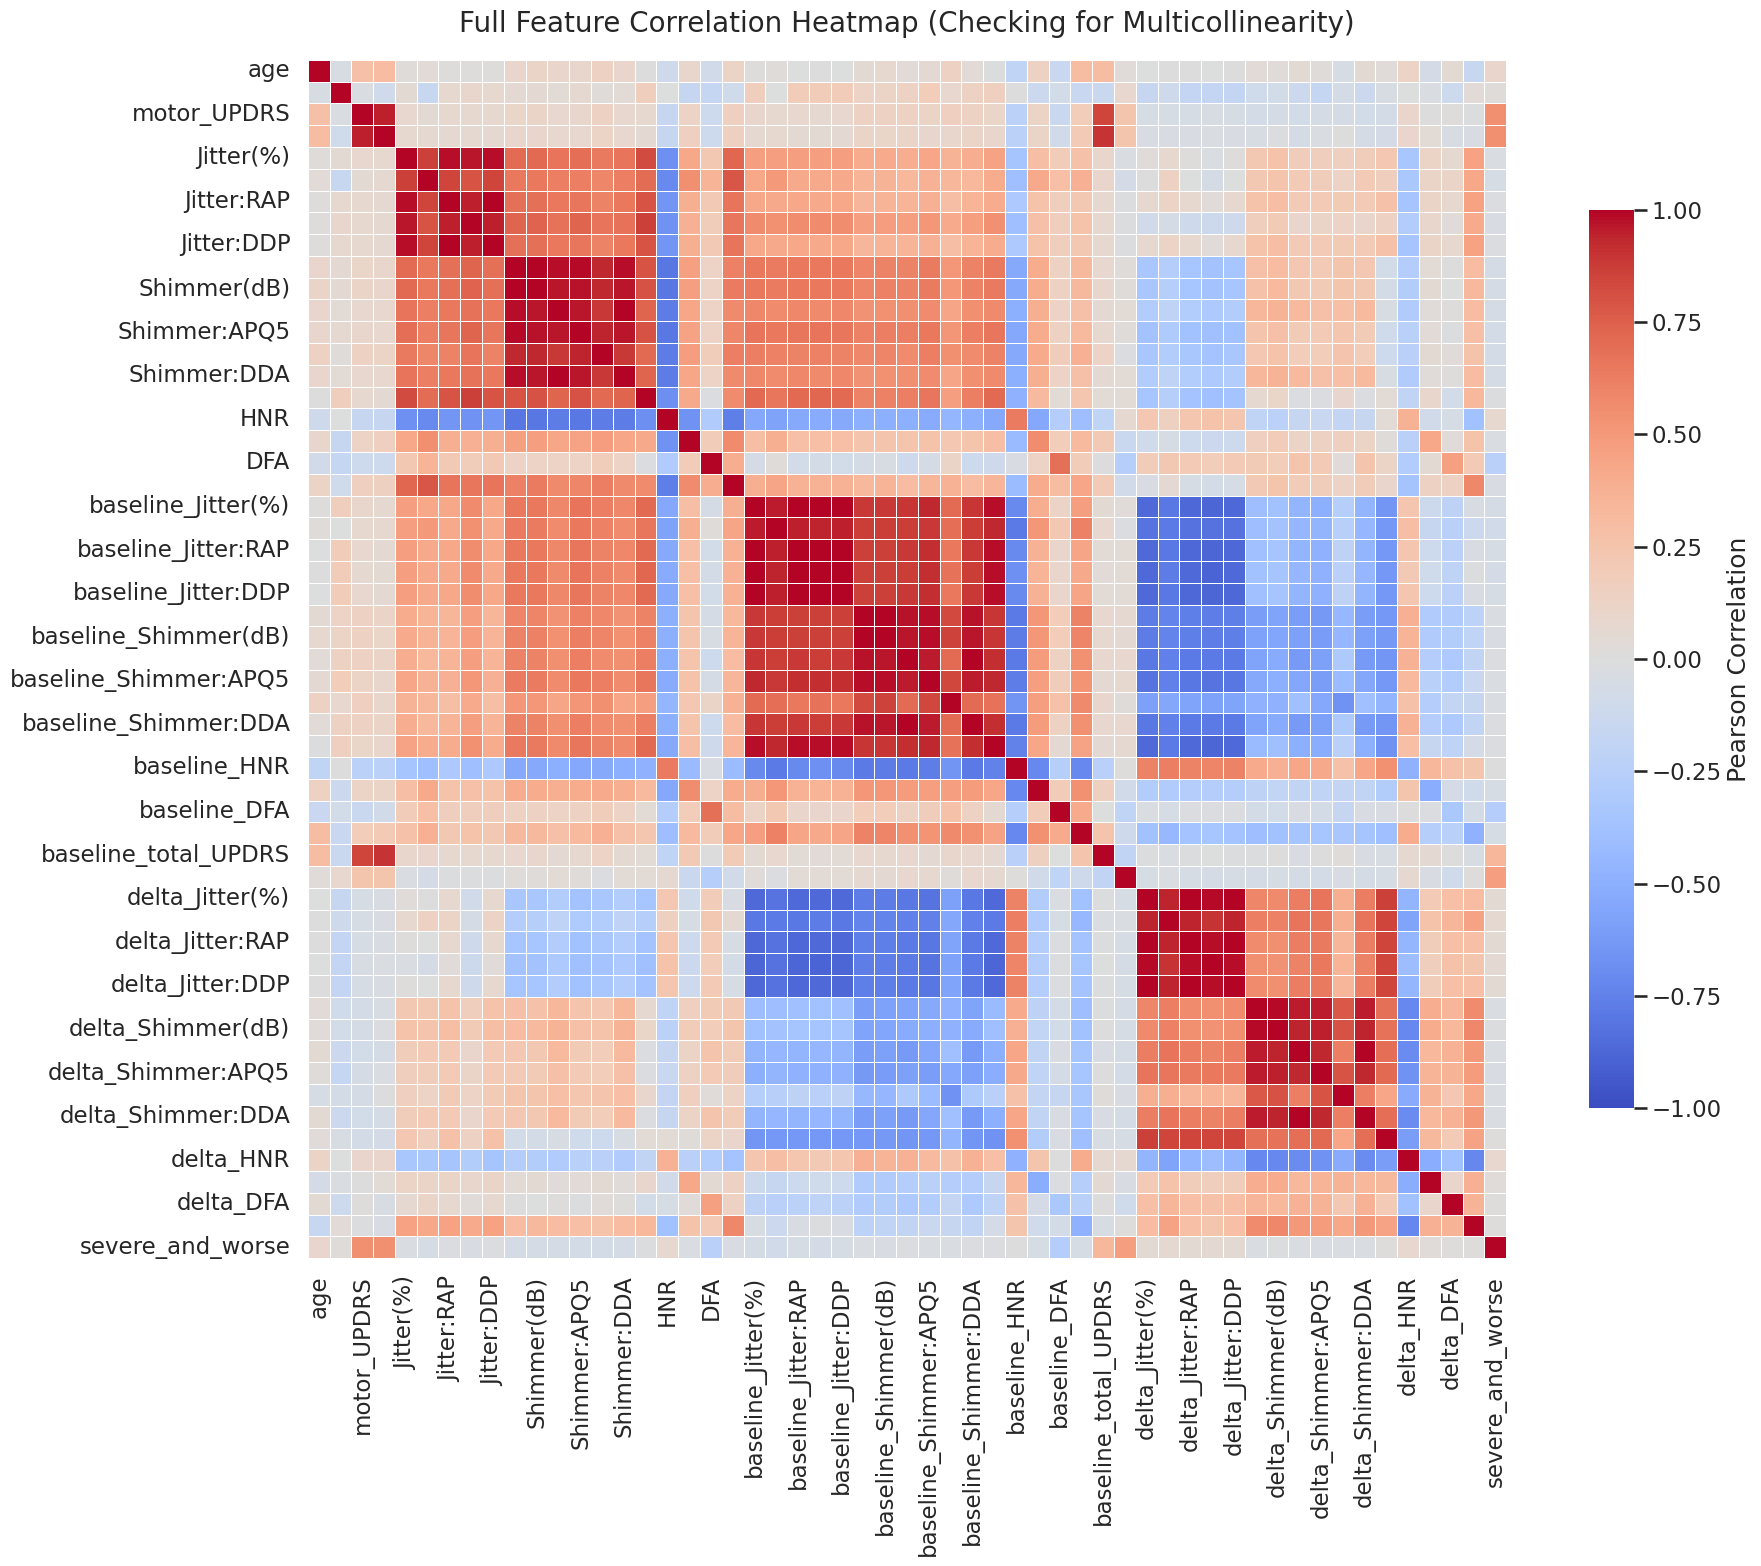

In [ ]:
plt.figure(figsize=(20, 16))

# Isolate numeric columns and drop metadata to focus entirely on acoustic/clinical features
num_df = df.select_dtypes(include=['number']).drop(columns=['subject#', 'test_time'], errors='ignore')

# Compute correlation matrix
full_corr_matrix = num_df.corr()

# Create the heatmap
sns.heatmap(
    full_corr_matrix,
    annot=False,
    cmap='coolwarm',
    vmin=-1, vmax=1,      # ADDED: Forces the scale to absolute limits, making high correlations darker
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .75, "label": "Pearson Correlation"}
)

plt.title('Full Feature Correlation Heatmap (Checking for Multicollinearity)', fontsize=20, pad=20)

# Display and Save
plt.tight_layout()
plt.savefig(f'{save_dir}4_full_correlation_heatmap.png', dpi=300)
plt.show()

**Interpretation:**
This heatmap visualizes the Pearson correlation between all numeric features. The large, dark-red blocks indicate dense clusters of **highly positively correlated features** (e.g., several distinct measurements of voice "Shimmer" or "Jitter" that essentially capture the exact same acoustic phenomenon). Leaving these redundant features in the dataset introduces multicollinearity, which inflates variance and makes our models less interpretable. Therefore, a strict correlation filter (>0.85 threshold) will be required in our pre-processing pipeline.

### More Data Preprocessing

In [ ]:

# CELL 4: HONEST SPLIT
drop_cols = (
    ['subject#', 'test_time', 'motor_UPDRS', 'total_UPDRS', 'delta_UPDRS', 'severe_and_worse']
    + voice_cols
)

X = df.drop(columns=drop_cols)
y = df['severe_and_worse']
groups = df['subject#']

# GroupShuffleSplit ensures patients aren't leaked across train/test sets
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

# MULTICOLLINEARITY FILTERING (Phase 2)
print(f"Original X_train shape: {X_train.shape}")

# 1. Calculate the absolute correlation matrix exclusively on the training set
corr_matrix = X_train.corr().abs()

# 2. Select only the upper triangle of the matrix
# Why? If feature A and B are 95% correlated, we only want to drop ONE of them.
# The upper triangle isolates unique pairs so we don't accidentally drop both.
import numpy as np
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Identify columns where the correlation exceeds a strict threshold (e.g., 0.85)
correlation_threshold = 0.85
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > correlation_threshold)]

print(f"\nIdentified {len(to_drop)} highly correlated features to drop.")
# print(f"Features dropping: {to_drop}") # Uncomment to see exactly which features are deleted

# 4. Drop these highly correlated features from BOTH X_train and X_test
X_train = X_train.drop(columns=to_drop)
X_test = X_test.drop(columns=to_drop)

print(f"\nNew X_train shape after dropping: {X_train.shape}")

# Plot 5: Correlation Heatmap (Filtered Features)
plt.figure(figsize=(24, 20)) # Create a large standalone figure

# Calculate correlation strictly on the filtered training set
filtered_corr_matrix = X_train.corr()

# Draw heatmap. annot=False is crucial here to prevent text overlap
sns.heatmap(filtered_corr_matrix, annot=False, cmap='coolwarm', cbar=True)
plt.title('5. Filtered Feature Correlation Heatmap', fontsize=18)

plt.tight_layout()
plt.savefig('filtered_correlation_heatmap.png', dpi=300)
plt.close()
print("Filtered correlation heatmap saved to filtered_correlation_heatmap.png")


Original X_train shape: (4640, 35)

Identified 22 highly correlated features to drop.

New X_train shape after dropping: (4640, 13)
Filtered correlation heatmap saved to filtered_correlation_heatmap.png


In [ ]:
# CELL 5: SOLVING CLASS IMBALANCE (SMOTE)
print(f"--- Before SMOTE (Train Set) ---")
print(f"Healthy (0): {sum(y_train == 0)} | Severe (1): {sum(y_train == 1)}")

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit and apply SMOTE to generate synthetic data on training set ONLY
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"--- After SMOTE (Train Set) ---")
print(f"Healthy (0): {sum(y_train_balanced == 0)} | Severe (1): {sum(y_train_balanced == 1)}\n")



--- Before SMOTE (Train Set) ---
Healthy (0): 3806 | Severe (1): 834
--- After SMOTE (Train Set) ---
Healthy (0): 3806 | Severe (1): 3806



In [ ]:
# CELL 6: FEATURE SCALING & ENGINEERING
# 1. Feature Scaling (Crucial for LR and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# 2. Add Polynomial Features for Logistic Regression (Forces non-linearity)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)



## Model Training And Evaluation

--- Extended Performance Evaluation ---

[SVM (RBF)]
  Accuracy: 94.90% | F1-Score (Macro): 85.62% | ROC/AUC: 0.9684


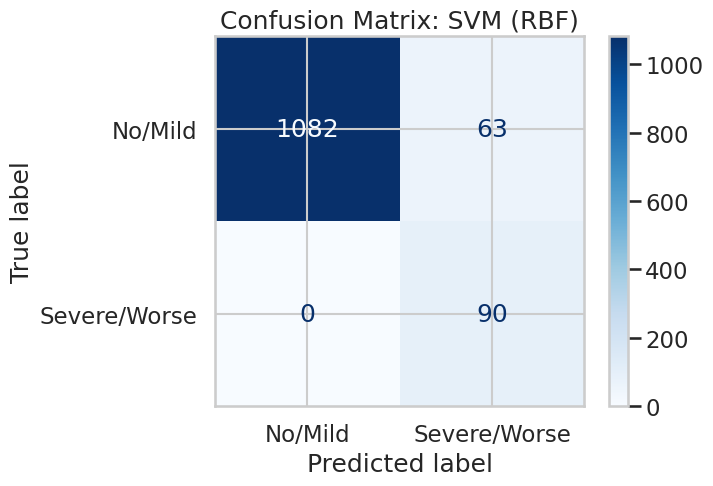

----------------------------------------
[Logistic Regression]
  Accuracy: 69.72% | F1-Score (Macro): 56.15% | ROC/AUC: 0.7560


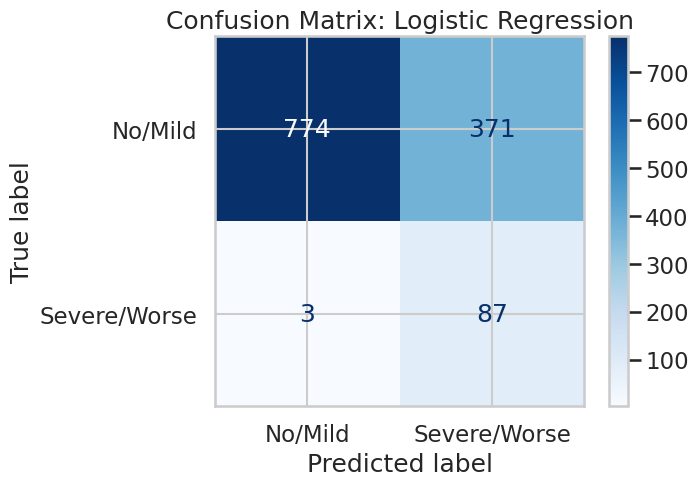

----------------------------------------
[Decision Tree]
  Accuracy: 94.74% | F1-Score (Macro): 85.27% | ROC/AUC: 0.9716


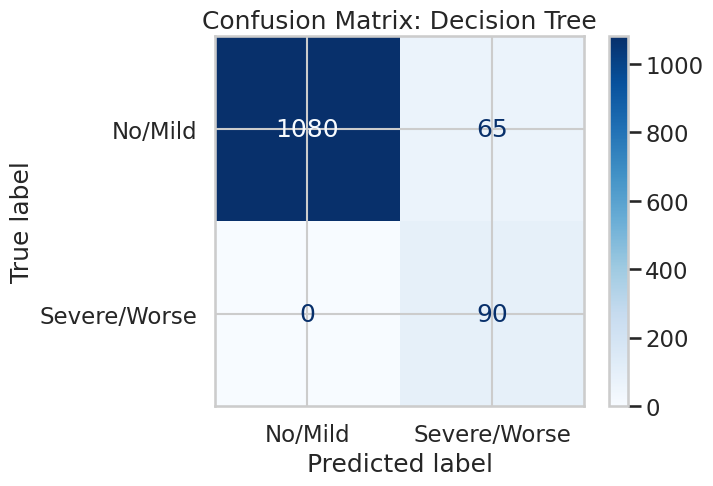

----------------------------------------
[Random Forest]
  Accuracy: 94.66% | F1-Score (Macro): 85.10% | ROC/AUC: 0.9685


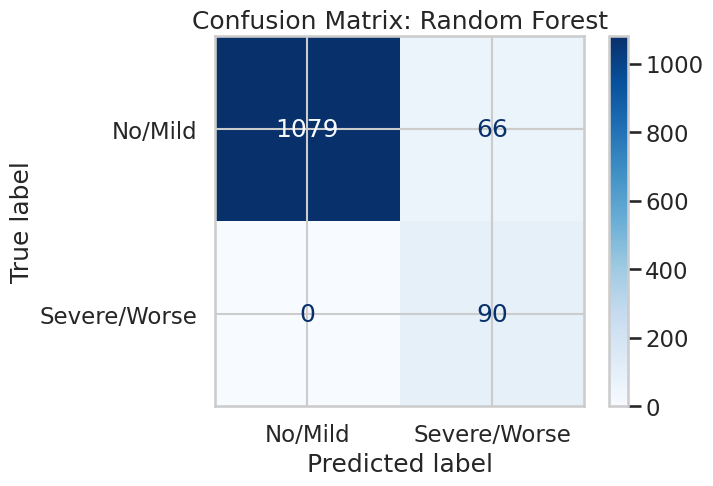

----------------------------------------
[K-Nearest Neighbors]
  Accuracy: 89.47% | F1-Score (Macro): 74.90% | ROC/AUC: 0.9349


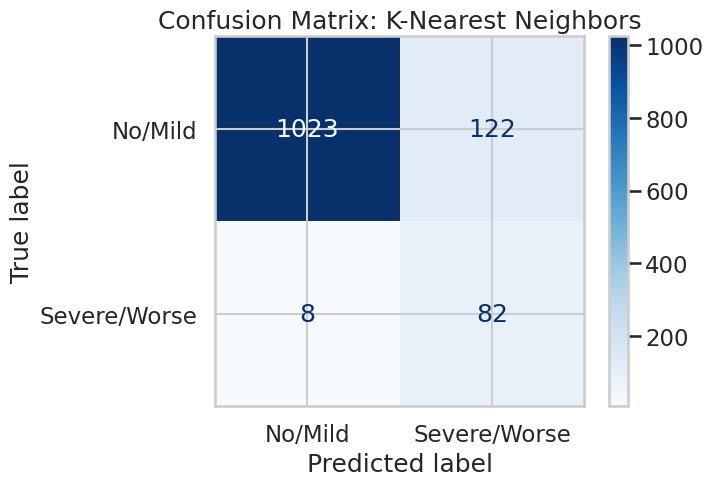

----------------------------------------


In [ ]:
# CELL 8: EVALUATE 5 MODELS
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Update Models Dictionary to include 5 models
models = {
    'SVM (RBF)': SVC(kernel='rbf', C=50.0, gamma='scale', class_weight='balanced', probability=True, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000, C=1.0, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=10, n_estimators=100),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, weights='distance')
}

print("--- Extended Performance Evaluation ---\n")

for name, model in models.items():
    # Route the correct data format
    if name == 'Logistic Regression':
        model.fit(X_train_poly, y_train_balanced)
        X_eval = X_test_poly
    else:
        model.fit(X_train_scaled, y_train_balanced)
        X_eval = X_test_scaled

    # Predict probabilities and apply optimal threshold logic
    y_probs_test = model.predict_proba(X_eval)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_test)
    f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]
    y_pred_screen = np.where(y_probs_test >= optimal_threshold, 1, 0)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_screen) * 100
    f1 = f1_score(y_test, y_pred_screen, average='macro') * 100
    auc = roc_auc_score(y_test, y_probs_test)

    print(f"[{name}]")
    print(f"  Accuracy: {acc:.2f}% | F1-Score (Macro): {f1:.2f}% | ROC/AUC: {auc:.4f}")

    # Generate Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_screen)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No/Mild', 'Severe/Worse'])
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()
    print("-" * 40)

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Initialize a list to store results
comparison_results = []

print("--- Generating Model Comparison Table ---\n")

for name, model in models.items():
    # 1. Route the correct data format
    if name == 'Logistic Regression':
        X_eval = X_test_poly
    else:
        X_eval = X_test_scaled

    # 2. Predict probabilities and find optimal threshold (as done in Cell 8)
    y_probs_test = model.predict_proba(X_eval)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_test)
    f1_scores_calc = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores_calc)
    optimal_threshold = thresholds[best_idx]

    # 3. Apply threshold to get final predictions
    y_pred = np.where(y_probs_test >= optimal_threshold, 1, 0)

    # 4. Calculate Metrics
    acc = accuracy_score(y_test, y_pred) * 100
    f1 = f1_score(y_test, y_pred, average='macro') * 100
    auc = roc_auc_score(y_test, y_probs_test)

    # 5. Extract Confusion Matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Append to results list
    comparison_results.append({
        "Model": name,
        "Accuracy (%)": round(acc, 2),
        "F1-Score (%)": round(f1, 2),
        "ROC-AUC": round(auc, 4),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Sort by F1-Score for better insight
comparison_df = comparison_df.sort_values(by="F1-Score (%)", ascending=False)

# Display the table
print(comparison_df.to_string(index=False))

# Optional: Save to CSV
comparison_df.to_csv("model_comparison_results.csv", index=False)

--- Generating Model Comparison Table ---

              Model  Accuracy (%)  F1-Score (%)  ROC-AUC   TN  FP  FN  TP
          SVM (RBF)         94.90         85.62   0.9684 1082  63   0  90
      Decision Tree         94.74         85.27   0.9716 1080  65   0  90
      Random Forest         94.66         85.10   0.9685 1079  66   0  90
K-Nearest Neighbors         89.47         74.90   0.9349 1023 122   8  82
Logistic Regression         69.72         56.15   0.7560  774 371   3  87
